# DataView: Exploração e Análise de Dados de Vendas

Mini-Projeto Avaliativo - Módulo 1 - Semana 08
Disciplina: Fundamentos de Dados, Programação e Análise Preditiva com Python

**Analista de Dados Júnior** simulando um relatório de vendas para a diretoria,
cobrindo todo o pipeline: carga, inspeção, limpeza, outliers, colunas derivadas,
métricas agregadas, segmentação de clientes, estatísticas com NumPy, visualizações,
funções reutilizáveis e exportação de relatórios (CSV/JSON).


## Passo 1 — Importação de Bibliotecas

In [54]:
import pandas as pd
import numpy as np
import random
import os
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


## RF01 — Criar ou Carregar o Dataset de Vendas

Geramos o dataset sinteticamente, com sujeira intencional (nulos, datas inválidas,
strings com espaços extras) para praticar a limpeza na RF03.

In [55]:
def gerar_dataset_vendas_vestuario(n_registros=15000, n_clientes=250, seed=42):
    """
    Gera um dataset sintético de vendas focado no segmento de vestuário e moda,
    incluindo intencionalmente dados sujos como valores nulos, strings com espaços,
    datas corrompidas e outliers de quantidade para testar o pipeline do projeto.
    Incorpora regras dinâmicas de cobrança de frete baseadas no canal de venda.
    """
    random.seed(seed)
    np.random.seed(seed)

    # 1. Portfólio focado em Vestuário com preços
    precos = {
        # Categoria: Roupas Masculinas
        'Camisa Polo Masculina': 129.90, 'Calça Jeans Casual': 189.90, 'Camiseta Básica Algodão': 49.90, 'Bermuda Sarja': 99.90,
        # Categoria: Roupas Femininas
        'Vestido Estampado Midi': 199.90, 'Blusa Crepe Feminina': 79.90, 'Calça Alfaiataria': 159.90, 'Saia Plissada': 119.90,
        # Categoria: Calçados
        'Ténis Desportivo Run': 349.90, 'Sapato Social Couro': 289.90, 'Sandália Salto Bloco': 149.90, 'Chinelo Slim Conforto': 39.90,
        # Categoria: Moda Íntima e Praia
        'Kit Cuecas Boxer 3un': 79.90, 'Conjunto Lingerie Renda': 119.90, 'Biquíni Cortininha': 139.90, 'Sunga de Praia': 69.90,
        # Categoria: Acessórios de Moda
        'Óculos de Sol Aviador': 179.90, 'Cinto de Couro': 69.90, 'Mochila Urbana': 219.90, 'Boné Ajustável Aba Curva': 59.90
    }

    # 2. Mapeamento das categorias de vestuário
    categorias = {
        'Camisa Polo Masculina': 'Moda Masculina', 'Calça Jeans Casual': 'Moda Masculina', 'Camiseta Básica Algodão': 'Moda Masculina', 'Bermuda Sarja': 'Moda Masculina',
        'Vestido Estampado Midi': 'Moda Feminina', 'Blusa Crepe Feminina': 'Moda Feminina', 'Calça Alfaiataria': 'Moda Feminina', 'Saia Plissada': 'Moda Feminina',
        'Ténis Desportivo Run': 'Calçados', 'Sapato Social Couro': 'Calçados', 'Sandália Salto Bloco': 'Calçados', 'Chinelo Slim Conforto': 'Calçados',
        'Kit Cuecas Boxer 3un': 'Moda Íntima e Praia', 'Conjunto Lingerie Renda': 'Moda Íntima e Praia', 'Biquíni Cortininha': 'Moda Íntima e Praia', 'Sunga de Praia': 'Moda Íntima e Praia',
        'Óculos de Sol Aviador': 'Acessórios', 'Cinto de Couro': 'Acessórios', 'Mochila Urbana': 'Acessórios', 'Boné Ajustável Aba Curva': 'Acessórios'
    }

    produtos = list(precos.keys())
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:04d}" for i in range(1, n_clientes + 1)]

    data_inicio = datetime(2024, 1, 1)
    dados = []
    
    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 3)
        preco = precos[produto]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # --- REGRAS DE SUJEIRA DO SEU PIPELINE ---
        if random.random() < 0.05: quantidade = None
        if random.random() < 0.04: preco = None
        if random.random() < 0.03: produto = "    " + produto + "  "
        if random.random() < 0.03: quantidade = random.randint(30, 80)
        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        # Define um custo padrão baseado em 45% do preço original
        custo = round(precos[produto.strip()] * 0.45, 2) if preco is not None else None
        
        # Sorteia tamanho baseado no tipo de produto 
        categoria_prod = categorias.get(produto.strip(), "Outros")
        tamanho = random.choice(['36', '38', '40', '42', '44']) if categoria_prod == 'Calçados' else random.choice(['P', 'M', 'G', 'GG'])
        
        # Sorteia cor 
        cor = random.choice(['Preto', 'Branco', 'Azul', 'Vermelho', 'Nude'])
        
        # Simula desconto (15% das vendas têm desconto aleatório entre 5% e 30%)
        desconto = round(random.uniform(0.05, 0.30), 2) if random.random() < 0.15 else 0.0
        
        # Forma de pagamento e parcelas coerentes
        forma_pgto = random.choice(['Cartão de Crédito', 'Pix', 'Boleto'])
        parcelas = random.randint(1, 12) if forma_pgto == 'Cartão de Crédito' else 1
        
        # Sorteia canal de venda
        canal_venda = random.choice(['E-commerce', 'App', 'Loja Física'])

        # Se for App ou E-commerce (Internet), sorteia um float de 20.00 a 100.00. Se for Loja Física, é 0.00.
        if canal_venda in ['App', 'E-commerce']:
            valor_frete = round(random.uniform(20.00, 100.00), 2)
        else:
            valor_frete = 0.00

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categoria_prod,
            "tamanho": tamanho,
            "cor": cor,
            "regiao": random.choice(regioes),
            "canal_venda": canal_venda, 
            "forma_pagamento": forma_pgto, 
            "parcelas": parcelas,
            "quantidade": quantidade,
            "preco_unitario": preco,
            "custo_unitario": custo, 
            "percentual_desconto": desconto,
            "valor_frete": valor_frete  # Inclusão do novo campo gerado
        })

    return pd.DataFrame(dados)

# Gerar e guardar na árvore de diretórios padrão do projeto
df_bruto = gerar_dataset_vendas_vestuario(n_registros=15000, n_clientes=250, seed=42)
os.makedirs('data/raw', exist_ok=True)
df_bruto.to_csv("data/raw/vendas.csv", index=False)

print(f"Dataset de vestuário gerado com {len(df_bruto):,} registros.")
df_bruto.head()


Dataset de vestuário gerado com 15,000 registros.


,id_venda,data_venda,cliente,produto,categoria,tamanho,cor,regiao,canal_venda,forma_pagamento,parcelas,quantidade,preco_unitario,custo_unitario,percentual_desconto,valor_frete
0,1,2024-05-20,Cliente_0007,Bermuda Sarja,Moda Masculina,GG,Preto,Norte,Loja Física,Boleto,1,1.0,99.9,44.96,0.1,0.00
1,2,2024-11-28,Cliente_0098,Calça Alfaiataria,Moda Feminina,M,Vermelho,Sudeste,App,Cartão de Crédito,4,3.0,159.9,71.95,0.0,28.18
2,3,2024-11-05,Cliente_0227,Chinelo Slim Conforto,Calçados,36,Nude,Nordeste,Loja Física,Boleto,1,2.0,39.9,17.95,0.0,0.00
3,4,2024-12-26,Cliente_0091,Mochila Urbana,Acessórios,P,Vermelho,Sul,App,Boleto,1,1.0,219.9,98.95,0.0,33.01
4,5,2024-12-15,Cliente_0143,Ténis Desportivo Run,Calçados,42,Azul,Sul,Loja Física,Boleto,1,3.0,349.9,157.45,0.0,0.00


## RF02 — Inspecionar e Descrever os Dados

In [56]:
def inspecionar_dados(df):
    """Exibe informações básicas do DataFrame."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f"\nEstatísticas descritivas:\n{df.describe()}")
    return df.describe(include="all")

resumo = inspecionar_dados(df_bruto)

# --- Demonstra while: iteração de verificação de qualidade ---
print("\n=== VERIFICAÇÃO DE QUALIDADE (while) ===")
colunas_check = ["quantidade", "preco_unitario", "data_venda", "produto"]
idx = 0
while idx < len(colunas_check):
    col = colunas_check[idx]
    n_nulos = int(df_bruto[col].isnull().sum())
    n_duplicados = int(df_bruto[col].duplicated().sum())
    status = "OK" if n_nulos == 0 else f"⚠ {n_nulos} nulos"
    print(f"  {col}: {status} | {n_duplicados} duplicados")
    idx += 1



=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (15000, 16)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'tamanho', 'cor', 'regiao', 'canal_venda', 'forma_pagamento', 'parcelas', 'quantidade', 'preco_unitario', 'custo_unitario', 'percentual_desconto', 'valor_frete']

Tipos de dados:
id_venda                 int64
data_venda                 str
cliente                    str
produto                    str
categoria                  str
tamanho                    str
cor                        str
regiao                     str
canal_venda                str
forma_pagamento            str
parcelas                 int64
quantidade             float64
preco_unitario         float64
custo_unitario         float64
percentual_desconto    float64
valor_frete            float64
dtype: object

Valores nulos por coluna:
id_venda                 0
data_venda               0
cliente                  0
produto                  0
categoria                0
tamanho              

## RF03 — Limpar e Tratar os Dados

Tratamos valores nulos em colunas críticas, datas inválidas e strings com espaços
extras (via expressões regulares), registrando um relatório do impacto de cada etapa.

In [57]:
def limpar_strings_regex(df, colunas):
    """
    Usa expressões regulares para normalizar colunas de texto:
    - Colapsa múltiplos espaços internos em um único espaço (re.sub)
    - Remove espaços nas pontas da string (.strip())
    - Preserva células nulas sem lançar erro (pd.notna)
    """
    df = df.copy()
    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s
        )
    return df


def exibir_relatorio_auditoria(relatorio):
    """
    Formata, alinha e renderiza o relatório final de auditoria com o cálculo
    de representação percentual para cada canal de exclusão do pipeline.
    """
    base_inicial = relatorio["registros_iniciais"]
    
    # Cálculo das proporções percentuais baseadas na volumetria de entrada
    pct_nulas_qtd = (relatorio["nulos_quantidade"] / base_inicial) * 100
    pct_nulas_prc = (relatorio["nulos_preco_unitario"] / base_inicial) * 100
    pct_subtotal_nulos = (relatorio["linhas_nulas_removidas"] / base_inicial) * 100
    pct_datas = (relatorio["datas_invalidas_removidas"] / base_inicial) * 100
    pct_removidos = (relatorio["registros_removidos_total"] / base_inicial) * 100
    pct_finais = (relatorio["registros_finais"] / base_inicial) * 100

    print("=" * 72)
    print(f"{'=== RELATÓRIO DE LIMPEZA E AUDITORIA ESTATÍSTICA ===':^72}")
    print("=" * 72)
    print(f" -> Registros Iniciais no Dataset:  {base_inicial:<8} [100.00%]")
    print("\n DETALHAMENTO DE EXCLUSÕES POR CATEGORIA/COLUNA:")
    print("-" * 72)
    print(" [Campos Nulos Detectados]")
    print(f"  • quantidade:                     {relatorio['nulos_quantidade']:<8} [{pct_nulas_qtd:>6.2f}%]")
    print(f"  • preco_unitario:                 {relatorio['nulos_preco_unitario']:<8} [{pct_nulas_prc:>6.2f}%]")
    print(f"   Subtotal de Linhas Nulas:        {relatorio['linhas_nulas_removidas']:<8} [{pct_subtotal_nulos:>6.2f}%]")
    print("\n [Inconsistências Cronológicas]")
    print(f"  • data_venda ('DATA INVALIDA'):   {relatorio['datas_invalidas_removidas']:<8} [{pct_datas:>6.2f}%]")
    print(f"   Subtotal de Datas Inválidas:     {relatorio['datas_invalidas_removidas']:<8} [{pct_datas:>6.2f}%]")
    print("-" * 72)
    print(f" -> Total de Registros Removidos:   {relatorio['registros_removidos_total']:<8} [{pct_removidos:>6.2f}%]")
    print(f" -> Registros Finais (Base Limpa):  {relatorio['registros_finais']:<8} [{pct_finais:>6.2f}%]")
    print("=" * 72)


def limpar_dados(df):
    """
    Limpa o DataFrame de vendas em quatro etapas:
    1. Normaliza strings com regex (espaços extras)
    2. Converte datas e remove registros com datas inválidas
    3. Remove linhas com valores nulos em colunas obrigatórias (mapeando a origem)
    4. Garante os tipos numéricos corretos
    Retorna: (df_limpo, relatorio)
    """
    df = df.copy()
    n_inicial = len(df)
    relatorio = {"registros_iniciais": n_inicial}

    # --- Etapa 1: limpeza de strings com regex ---
    colunas_texto = df.select_dtypes(include="string").columns
    df = limpar_strings_regex(df, colunas_texto)

    # --- Etapa 2: conversão de datas ---
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])

    # --- Etapa 3: contagem e remoção de nulos por coluna ---
    # Capturamos os nulos individuais antes que o dropna remova a linha inteira
    relatorio["nulos_quantidade"] = int(df["quantidade"].isnull().sum())
    relatorio["nulos_preco_unitario"] = int(df["preco_unitario"].isnull().sum())
    
    n_antes_nulos = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes_nulos - len(df)

    # --- Etapa 4: garantia de tipos numéricos ---
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # Consolidação dos metadados volumétricos finais
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)

    return df, relatorio


# =========================================================================
# EXECUÇÃO DO PIPELINE
# =========================================================================
# Executa a limpeza estrutural e gera a tabela estável v1
df_v1, relatorio = limpar_dados(df_bruto)

# Exibe relatório
exibir_relatorio_auditoria(relatorio)


# Salva a versão limpa (outliers mantidos)
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)
df_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)
print("\n[OK] Versão v1 gravada com sucesso em: data/processed/v1_com_outliers/vendas_v1.csv\n")
df_v1.head()


C:\Users\claudio.rodrigues\AppData\Local\Temp\ipykernel_31772\2046282961.py:64: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


          === RELATÓRIO DE LIMPEZA E AUDITORIA ESTATÍSTICA ===          
 -> Registros Iniciais no Dataset:  15000    [100.00%]

 DETALHAMENTO DE EXCLUSÕES POR CATEGORIA/COLUNA:
------------------------------------------------------------------------
 [Campos Nulos Detectados]
  • quantidade:                     750      [  5.00%]
  • preco_unitario:                 590      [  3.93%]
   Subtotal de Linhas Nulas:        1307     [  8.71%]

 [Inconsistências Cronológicas]
  • data_venda ('DATA INVALIDA'):   291      [  1.94%]
   Subtotal de Datas Inválidas:     291      [  1.94%]
------------------------------------------------------------------------
 -> Total de Registros Removidos:   1598     [ 10.65%]
 -> Registros Finais (Base Limpa):  13402    [ 89.35%]

[OK] Versão v1 gravada com sucesso em: data/processed/v1_com_outliers/vendas_v1.csv



,id_venda,data_venda,cliente,produto,categoria,tamanho,cor,regiao,canal_venda,forma_pagamento,parcelas,quantidade,preco_unitario,custo_unitario,percentual_desconto,valor_frete
0,1,2024-05-20,Cliente_0007,Bermuda Sarja,Moda Masculina,GG,Preto,Norte,Loja Física,Boleto,1,1,99.9,44.96,0.1,0.00
1,2,2024-11-28,Cliente_0098,Calça Alfaiataria,Moda Feminina,M,Vermelho,Sudeste,App,Cartão de Crédito,4,3,159.9,71.95,0.0,28.18
2,3,2024-11-05,Cliente_0227,Chinelo Slim Conforto,Calçados,36,Nude,Nordeste,Loja Física,Boleto,1,2,39.9,17.95,0.0,0.00
3,4,2024-12-26,Cliente_0091,Mochila Urbana,Acessórios,P,Vermelho,Sul,App,Boleto,1,1,219.9,98.95,0.0,33.01
4,5,2024-12-15,Cliente_0143,Ténis Desportivo Run,Calçados,42,Azul,Sul,Loja Física,Boleto,1,3,349.9,157.45,0.0,0.00


## RF04 — Detectar e Tratar Outliers (versões v1 e v2)

Detectamos outliers em `quantidade` e `receita_total` pelo método IQR. A v1 mantém
os outliers; a v2 reaproveita a mesma função de limpeza/tratamento para gerar uma
base sem outliers.

In [58]:
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """
    Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).

    Parâmetros:
        colunas : lista de colunas numéricas a verificar
        fator   : multiplicador do IQR para definir os limites (padrão=1.5)
        metodo  : 'remover' exclui as linhas com outliers;
                  'limitar' aplica winsorização (substitui pelo limite)

    Retorna o DataFrame tratado sem modificar o original (usa .copy()).
    """
    df = df.copy()
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr

        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f'  {col}: {n_out} outliers detectados '
              f'(lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})')

        if metodo == 'remover':
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    return df


# Cópia temporária só para calcular receita_total e detectar outliers
df_v1_tmp = df_v1.copy()
df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

df_v2 = tratar_outliers(
    df_v1_tmp,
    colunas=["quantidade", "receita_total"],
    metodo='remover'
)
df_v2 = df_v2.drop(columns=["receita_total"])  # será recriada no RF05

print(f"\nv1 = {len(df_v1)} linhas (com outliers)")
print(f"v2 = {len(df_v2)} linhas (outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")

os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)
df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
print("\nv2 salva em data/processed/v2_outliers_tratado/")


  quantidade: 428 outliers detectados (lim_inf=-2.00, lim_sup=6.00)
  receita_total: 418 outliers detectados (lim_inf=-214.95, lim_sup=704.65)

v1 = 13402 linhas (com outliers)
v2 = 12556 linhas (outliers removidos)
Diferença = 846 linhas removidas

v2 salva em data/processed/v2_outliers_tratado/


## RF05 — Criar Colunas Derivadas com Transformações

A partir daqui usamos `df_v2` (outliers tratados) como base oficial da análise.

In [59]:
def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
    - receita_total     : valor total da linha de venda (quantidade × preço)
    - mes / trimestre / ano : componentes extraídos da data
    - faixa_receita_item    : classificação do valor de cada venda (np.select)
    """
    df = df.copy()

    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year

    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("COLUNAS DERIVADAS CRIADAS")
    print(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())

    return df


df = criar_colunas_derivadas(df_v2)
df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head()


COLUNAS DERIVADAS CRIADAS
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-05-20           99.9    5        Q2        Baixo Valor
1 2024-11-28          479.7   11        Q4        Baixo Valor
2 2024-11-05           79.8   11        Q4        Baixo Valor
3 2024-12-26          219.9   12        Q4        Baixo Valor
5 2024-04-27          149.9    4        Q2        Baixo Valor


,data_venda,receita_total,mes,trimestre,faixa_receita_item
0,2024-05-20,99.9,5,Q2,Baixo Valor
1,2024-11-28,479.7,11,Q4,Baixo Valor
2,2024-11-05,79.8,11,Q4,Baixo Valor
3,2024-12-26,219.9,12,Q4,Baixo Valor
5,2024-04-27,149.9,4,Q2,Baixo Valor


## RF06 — Calcular Métricas Agregadas (groupby)

In [60]:
def calcular_metricas(df):
    """
    Calcula e retorna um dicionário com métricas agregadas por
    quatro dimensões: mês, produto, categoria e região.
    """
    metricas = {}

    metricas["por_mes"] = (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade", "sum"),
            n_vendas=("id_venda", "count"),
        )
        .reset_index()
        .sort_values("mes")
    )

    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    metricas["por_regiao"] = (
        df.groupby("regiao")
        .agg(
            receita_total=("receita_total", "sum"),
            media_ticket=("receita_total", "mean"),
        )
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))

    return metricas


metricas = calcular_metricas(df)



=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       247439.3        2007      1043
   2       255679.7        2003      1001
   3       277848.8        2112      1076
   4       278777.3        2127      1079
   5       279847.5        2125      1087
   6       252731.9        1981      1008
   7       267029.2        2008      1027
   8       264365.9        2041      1055
   9       258802.7        1973      1002
  10       263638.1        2019      1036
  11       266033.0        2070      1062
  12       273751.1        2089      1080

=== TOP PRODUTOS ===
               produto  receita_total
        Mochila Urbana       280812.3
Vestido Estampado Midi       271864.0
    Calça Jeans Casual       233197.2
  Ténis Desportivo Run       225685.5
 Óculos de Sol Aviador       222356.4

=== POR CATEGORIA ===
          categoria  receita_total
      Moda Feminina       752103.3
         Acessórios       675322.9
           Calçados       646935.0
     Moda Masculina     

## RF07 — Segmentar Clientes por Nível de Gasto

| Gasto Total | Segmento |
|---|---|
| Abaixo de R$ 5.000 | Bronze |
| R$ 5.000 a R$ 15.000 | Prata |
| Acima de R$ 15.000 | Ouro |

In [61]:
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente, calcula o total gasto por cada um
    e classifica em Bronze / Prata / Ouro usando uma função lambda
    com condicional encadeado (equivalente a if/elif/else).
    """
    clientes_df = (
        df.groupby("cliente")["receita_total"]
        .sum()
        .reset_index()
    )
    clientes_df.columns = ["cliente", "total_gasto"]

    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)

    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")

    return clientes_df


clientes = segmentar_clientes(df)
clientes.head()


=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
     cliente  total_gasto segmento
Cliente_0178      18295.5     Ouro
Cliente_0147      17867.0     Ouro
Cliente_0162      17518.3     Ouro
Cliente_0142      17438.2     Ouro
Cliente_0003      17335.9     Ouro
Cliente_0017      17109.1     Ouro
Cliente_0165      17107.3     Ouro
Cliente_0014      17099.2     Ouro
Cliente_0130      17067.5     Ouro
Cliente_0223      17037.5     Ouro

Distribuição de segmentos:
segmento
Prata    214
Ouro      36
Name: count, dtype: int64


,cliente,total_gasto,segmento
177,Cliente_0178,18295.5,Ouro
146,Cliente_0147,17867.0,Ouro
161,Cliente_0162,17518.3,Ouro
141,Cliente_0142,17438.2,Ouro
2,Cliente_0003,17335.9,Ouro


## RF08 — Calcular Estatísticas com NumPy

Demonstra conversão para array, operações vetorizadas, broadcasting e boolean
indexing.

In [62]:
def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra: operações vetorizadas, broadcasting e boolean indexing.
    """
    receitas = df["receita_total"].to_numpy()

    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total": float(np.sum(receitas)),
        "p25": float(np.percentile(receitas, 25)),
        "p75": float(np.percentile(receitas, 75)),
    }

    # Broadcasting: participação percentual de cada venda no total
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"  Participação das 5 maiores vendas no total: "
          f"{np.sort(receitas_pct)[-5:].round(2)}%")

    # Boolean indexing
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} vendas")
        else:
            print(f"  {k}: R$ {v:.2f}")

    return stats


stats = calcular_estatisticas_numpy(df)


  Participação das 5 maiores vendas no total: [0.02 0.02 0.02 0.02 0.02]%

=== ESTATÍSTICAS COM NUMPY ===
  media: R$ 253.74
  mediana: R$ 209.70
  desvio_padrao: R$ 163.41
  total: R$ 3185944.50
  p25: R$ 129.90
  p75: R$ 359.70
  acima_da_media: 4887 vendas


## RF09 — Criar Visualizações com Matplotlib e Seaborn

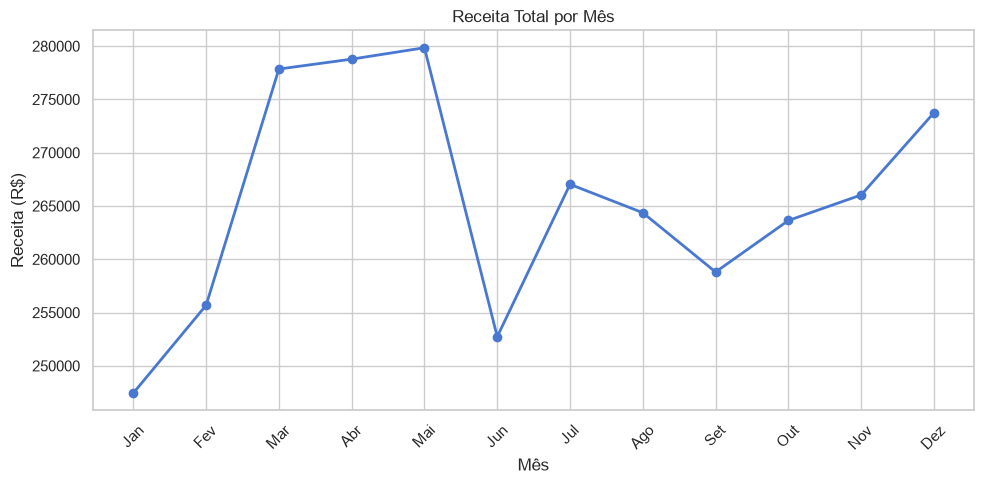

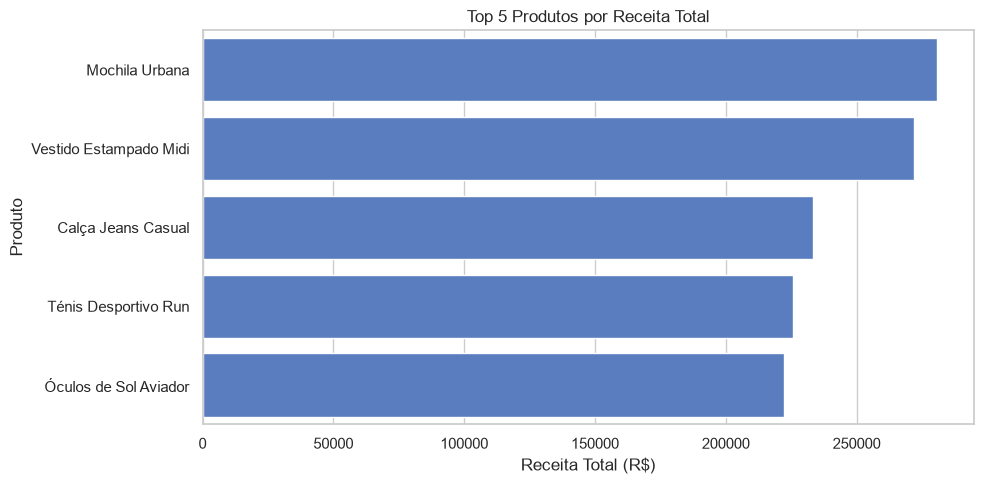

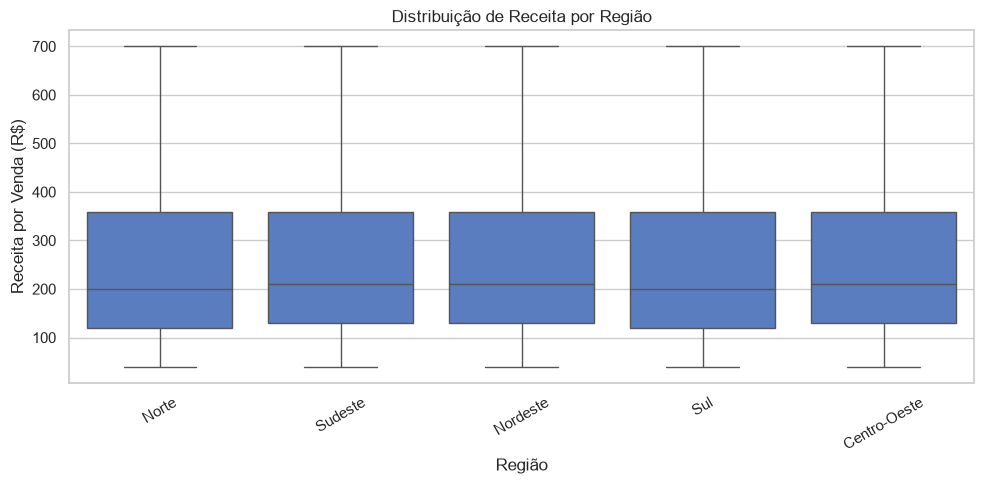

3 gráficos salvos em: outputs/graficos


In [63]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG:
    1. Linha    — receita total por mês
    2. Barras   — top 5 produtos por receita
    3. Boxplot  — distribuição de receita por região
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun",
                   "Jul","Ago","Set","Out","Nov","Dez"]

    # Gráfico 1: Linha — Receita por Mês
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 2: Barras Horizontais — Top 5 Produtos
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 3: Boxplot — Distribuição de Receita por Região
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show()
    plt.close()

    print(f"3 gráficos salvos em: {output_dir}")


gerar_visualizacoes(df, metricas)


## RF10 — Organizar o Código em Funções Reutilizáveis

Todas as etapas acima já estão encapsuladas em funções com docstring, parâmetros e
retorno explícito (`limpar_dados`, `tratar_outliers`, `criar_colunas_derivadas`,
`calcular_metricas`, `segmentar_clientes`, `calcular_estatisticas_numpy`,
`gerar_visualizacoes`). A função `limpar_dados` foi reutilizada implicitamente como
base tanto para a v1 quanto para a v2 (via `tratar_outliers` sobre o resultado de
`limpar_dados`).

Abaixo, demonstramos uma função de ordem superior (callback) e o segundo uso
distinto de `lambda` no projeto.

In [64]:
def aplicar_transformacao(df, coluna, funcao):
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.

    Parâmetros:
        df     : DataFrame de entrada
        coluna : nome da coluna a transformar
        funcao : função (ou lambda) a aplicar — o 'callback'

    Retorna uma cópia do DataFrame com a nova coluna; não modifica o original.
    """
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df


# --- Uso 1: classificar vendas por ticket com lambda ---
df_demo = aplicar_transformacao(
    df, "receita_total", lambda x: "Alto" if x > 5000 else "Normal"
)
print("=== EXEMPLO: classificação por ticket ===")
print(df_demo[["receita_total", "receita_total_transformado"]].head())

# --- Uso 2: arredondar receita em milhares com lambda ---
df_demo2 = aplicar_transformacao(
    df, "receita_total", lambda x: round(x / 1000, 2)
)
print("\n=== EXEMPLO: receita em milhares (R$ k) ===")
print(df_demo2[["receita_total", "receita_total_transformado"]].head())
# df_demo e df_demo2 são apenas demonstrações — df principal não é alterado.


=== EXEMPLO: classificação por ticket ===
   receita_total receita_total_transformado
0           99.9                     Normal
1          479.7                     Normal
2           79.8                     Normal
3          219.9                     Normal
5          149.9                     Normal

=== EXEMPLO: receita em milhares (R$ k) ===
   receita_total  receita_total_transformado
0           99.9                        0.10
1          479.7                        0.48
2           79.8                        0.08
3          219.9                        0.22
5          149.9                        0.15


## RF11 — Ler e Escrever Arquivos (CSV e JSON)

In [65]:
def exportar_resultados(metricas, clientes, stats):
    """
    Exporta os resultados da análise em dois formatos:
    - CSV : métricas mensais e segmentação de clientes
    - JSON: estatísticas gerais calculadas com NumPy

    Após exportar o JSON, faz a leitura de volta com json.load()
    para confirmar que o arquivo foi gravado corretamente.
    """
    os.makedirs("outputs", exist_ok=True)

    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/metricas_por_mes.csv")

    clientes.to_csv(
        "outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print("CSV exportado: outputs/segmentacao_clientes.csv")

    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = "outputs/estatisticas_gerais.json"
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"JSON exportado: {caminho_json}")

    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("\nJSON lido de volta para confirmação:")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


exportar_resultados(metricas, clientes, stats)


CSV exportado: outputs/metricas_por_mes.csv
CSV exportado: outputs/segmentacao_clientes.csv
JSON exportado: outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": 253.74,
  "mediana": 209.7,
  "desvio_padrao": 163.41,
  "total": 3185944.5,
  "p25": 129.9,
  "p75": 359.7,
  "acima_da_media": 4887.0
}


## RF12 — Consolidar a Análise e Salvar o Dataset Final

Optamos por **df_v2 (outliers removidos)** como base da análise final — ela reflete
melhor o comportamento típico de vendas para a reunião da diretoria. A v1 (com
outliers) continua disponível em `data/processed/v1_com_outliers/` para consulta.

In [66]:
os.makedirs("data/final", exist_ok=True)
df.to_csv("data/final/vendas_final.csv", index=False)
print("Dataset final salvo em: data/final/vendas_final.csv")

# Verificação dos arquivos esperados
arquivos_esperados = [
    "data/raw/vendas.csv",
    "data/processed/v1_com_outliers/vendas_v1.csv",
    "data/processed/v2_outliers_tratado/vendas_v2.csv",
    "data/final/vendas_final.csv",
    "outputs/metricas_por_mes.csv",
    "outputs/segmentacao_clientes.csv",
    "outputs/estatisticas_gerais.json",
    "outputs/graficos/receita_por_mes.png",
    "outputs/graficos/top_produtos.png",
    "outputs/graficos/dist_regiao.png",
]

print("\n=== CHECKLIST DE ARQUIVOS GERADOS ===")
for arq in arquivos_esperados:
    status = "OK" if os.path.exists(arq) else "FALTANDO"
    print(f"  [{status}] {arq}")


Dataset final salvo em: data/final/vendas_final.csv

=== CHECKLIST DE ARQUIVOS GERADOS ===
  [OK] data/raw/vendas.csv
  [OK] data/processed/v1_com_outliers/vendas_v1.csv
  [OK] data/processed/v2_outliers_tratado/vendas_v2.csv
  [OK] data/final/vendas_final.csv
  [OK] outputs/metricas_por_mes.csv
  [OK] outputs/segmentacao_clientes.csv
  [OK] outputs/estatisticas_gerais.json
  [OK] outputs/graficos/receita_por_mes.png
  [OK] outputs/graficos/top_produtos.png
  [OK] outputs/graficos/dist_regiao.png


## Conclusão

O pipeline DataView percorreu todo o ciclo de um Analista de Dados Júnior:
carga e inspeção do dataset bruto, limpeza (nulos, datas, strings), detecção e
tratamento de outliers em duas versões (v1/v2), criação de colunas derivadas,
agregações com `groupby`, segmentação de clientes, estatísticas vetorizadas com
NumPy, visualizações exportadas em PNG e relatórios finais em CSV/JSON.

Próximos passos sugeridos:
- Adicionar testes automatizados para as funções de limpeza;
- Parametrizar os limites de segmentação de clientes;
- Conectar a um dataset real (Kaggle / dados.gov.br) para validar a generalização.
